In [1]:
import os
import json
import torch
import torch.nn as nn
from torch.optim import AdamW
import torch.nn.functional as functional
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

/Users/lorenaandravacarean/Desktop/Fake News/Model/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/lorenaandravacarean/Desktop/Fake News/Model/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "roberta-base"
LABELS = ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]
LABEL2ID = {lbl: i for i, lbl in enumerate(LABELS)}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

In [3]:
LABEL2ID

{'SUPPORTS': 0, 'REFUTES': 1, 'NOT ENOUGH INFO': 2}

In [4]:
ID2LABEL

{0: 'SUPPORTS', 1: 'REFUTES', 2: 'NOT ENOUGH INFO'}

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [6]:
device

device(type='mps')

### Helper functions to load datasets

In [7]:
import pandas as pd

In [18]:
def load_multifc_claims(path_):
    data_list = []
    df = pd.read_json(path_, lines=True)
    
    for idx, row in df.iterrows():
        claim_text = row["claim"]
        label_str = row["label"]
        label_id = LABEL2ID.get(label_str)
        
        data_list.append({
            "claim": claim_text,
            "label_id": label_id
        })

    return data_list

In [8]:
def load_fever_claims(path_):
    data_list = []
    df = pd.read_json(path_, lines=True)

    for idx, row in df.iterrows():
        claim_text = row["claim"]
        evidence_text = row.get("evidence_text", "")
        label_str = row["label"]
        label_id = LABEL2ID.get(label_str)
        data_list.append({
            "claim": claim_text,
            "evidence": evidence_text,
            "label_id": label_id
        })
    
    return data_list

## Dataset Classes

### Claim-Only (MultiFC)

In [19]:
class MultiFCDataset(Dataset):
    
    def __init__(self, data_list, tokenizer, max_len=128):
        self.data_list = data_list
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        sample = self.data_list[idx]
        claim_text = sample["claim"]
        label_id = sample["label_id"]

        encoded = self.tokenizer(
            text=claim_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        # return item only (from (1, max_len) to (max_len))
        input_ids = encoded["input_ids"].squeeze(0)
        attn_mask = encoded["attention_mask"].squeeze(0)

        return {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "label": torch.tensor(label_id, dtype=torch.long)
        }

### Claim + Evidence (FEVER)

In [9]:
class FeverDataset(Dataset):

    def __init__(self, data_list, tokenizer, max_len=256):
        self.data_list = data_list
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        sample = self.data_list[idx]
        claim_text = sample["claim"]
        evidence_text = sample["evidence"]
        label_id = sample["label_id"]

        encoded = self.tokenizer(
            text=claim_text,
            text_pair=evidence_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze(0)
        attn_mask = encoded["attention_mask"].squeeze(0)

        return {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "label": torch.tensor(label_id, dtype=torch.long)
        }

## Model

In [10]:
class BiGRUCNNClassifier(nn.Module):

    def __init__(self, roberta_name="roberta-base", hidden_size=128, num_labels=3):
        super().__init__()
        # STEP 1: load RoBERTa as the encoder
        self.roberta = AutoModel.from_pretrained(roberta_name)

        # STEP 2: BiGRU
        # roberta output: 768 dimensional embeddings
        self.gru = nn.GRU(
            input_size=768,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        # STEP 3: CNN
        self.conv1 = nn.Conv1d(
            in_channels=2*hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )

        # STEP 4: Max-pooling
        self.pool = nn.AdaptiveMaxPool1d(1)

        # STEP 5: Fully Connected Layer
        self.classifier = nn.Linear(128, num_labels)


    def forward(self, input_ids, attention_mask):
        # STEP 1: RoBERTa embeddings
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        token_embeds = outputs.last_hidden_state

        # STEP 2: BiGRU -> [B, T, 2*hidden_size]
        gru_out, _ = self.gru(token_embeds)

        # STEP 3: CNN -> [B, 128, T]
        x = gru_out.permute(0, 2, 1) # din [B, T, 2*hidden_size] in [B, 2*hidden_size, T]
        x = torch.relu(self.conv1(x))
        x = self.pool(x).squeeze(2) # [B, 128]

        # STEP 4: FC
        logits = self.classifier(x)
        return logits

In [11]:
def freeze_roberta_layers(model, num_layers_unfrozen=0):
    """
    we freeze the base layers to protect the pre-trained weights (the capability to understand language)
    if num_layers_unfrozen == 0 -> freeze entire roberta
    if == 1 -> unfreeze last layer (layer.l1 in roberta-base)
    """
    total_layers = 12
    freeze_until = total_layers - num_layers_unfrozen

    for name, param in model.roberta.named_parameters():
        if "embeddings" in name:
            param.requires_grad = False
			
        else:
            split_ = name.split(".")
            if len(split_) >= 4 and split_[3] == "layer":
                layer_idx = int(split_[3])

                if layer_idx < freeze_until:
                    param.requires_grad = False
                else:
                    param.requires_grad = True
            else:
                param.requires_grad = True

## STAGE 1 TRAINING: CLAIM ONLY

In [12]:
from sklearn.metrics import f1_score

In [13]:
multifc_path = os.path.join(os.getcwd(), "Dataset", "multifc")
output_claim_only_path = os.path.join(os.getcwd(), "claim-only")

In [14]:
output_claim_only_path

'/Users/lorenaandravacarean/Desktop/Fake News/Model/claim-only'

In [15]:
def train_stage1_claim_only(
	multifc_path=multifc_path,
	output_path=output_claim_only_path,
	roberta_name=MODEL_NAME,
	batch_size=16,
	freeze_until=10,
	lr=1e-4,
	epochs=3,
	max_len=128,
	log_interval=100,
	nr_model=0
):
	print("===== STAGE 1: TRAIN ON MULTIFC (CLAIM-ONLY) =====")
	tokenizer = AutoTokenizer.from_pretrained(roberta_name)
	train_path = os.path.join(multifc_path, "train.json")
	val_path = os.path.join(multifc_path, "validation.json")

	data_list_train = load_multifc_claims(train_path)
	data_list_val = load_multifc_claims(val_path)

	print("Creating datasets and dataloaders...")
	train_ds = MultiFCDataset(data_list_train, tokenizer, max_len=max_len)
	val_ds = MultiFCDataset(data_list_val, tokenizer, max_len=max_len)

	train_loader = DataLoader(train_ds, batch_size=batch_size)
	val_loader = DataLoader(val_ds, batch_size=batch_size)

	print("Initializing model...")
	model = BiGRUCNNClassifier(roberta_name=roberta_name,
								hidden_size=128,
								num_labels=3)
	model.to(device)

	print(f"Freezing bottom {freeze_until} layers of RoBERTa...")
	# freeze bottom layers of roberta
	# we unfreeze the top 12 - freeze_until (10)
	freeze_roberta_layers(model, num_layers_unfrozen=(12 - freeze_until))

	print("Setting up optimizer and scheduler...")
	# optimizer - trainable params only
	optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
	criterion = nn.CrossEntropyLoss()


	total_steps = len(train_loader) * epochs
	scheduler = get_linear_schedule_with_warmup(
		optimizer,
		num_warmup_steps=int(0.1 * total_steps),
		num_training_steps=total_steps
	)


	model.train()
	for epoch in range(1, epochs+1):
			
		running_loss = 0.0
		total_loss = 0.0
		
		for i, batch in enumerate(train_loader, 1):
			input_ids = batch["input_ids"].to(device)
			attn_mask = batch["attention_mask"].to(device)
			labels = batch["label"].to(device)

			# forward pass
			logits = model(input_ids, attn_mask)
			loss = criterion(logits, labels)

			# backpropagation + update
			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			if scheduler is not None:
				scheduler.step()

			running_loss += loss.item()
			total_loss += loss.item()

			if i % log_interval == 0:
				avg_partial_loss = running_loss / log_interval
				print(f"[Epoch {epoch} | Step {i}] loss={avg_partial_loss:.4f}")
				running_loss = 0.0
		
		avg_train_loss = total_loss / len(train_loader)
		print(f">>> Epoch {epoch} average train loss: {avg_train_loss:.4f}")

		### Validation
		model.eval()
		correct = 0
		total = 0
		val_loss = 0.0

		all_preds = []
		all_labels = []

		with torch.no_grad():
			for batch in val_loader:
				input_ids = batch["input_ids"].to(device)
				attn_mask = batch["attention_mask"].to(device)
				labels = batch["label"].to(device)

				outputs = model(input_ids, attn_mask)
				v_loss = criterion(outputs, labels)
				val_loss += v_loss.item()

				preds = torch.argmax(outputs, dim=1)

				all_preds.extend(preds.cpu().numpy())
				all_labels.extend(labels.cpu().numpy())

				correct += (preds == labels).sum().item()
				total += labels.size(0)

		val_f1 = f1_score(all_labels, all_preds, average="macro")
		avg_val_loss = val_loss / len(val_loader)
		val_acc = correct / total

		all_preds.clear()
		all_labels.clear()

		print(f"Epoch [{epoch}/{epochs}] Val loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

	hyperparams = {
		"lr": lr,
		"epochs": epochs,
		"freeze_until": freeze_until
	}
	checkpoint = {
		"model_state": model.state_dict(),
		"hyperparams": hyperparams
	}
	output_path_ = os.path.join(output_path, f"stage1_claim_only{nr_model}.pth")
	torch.save(checkpoint, output_path_)
	print(f"Stage 1 model saved to {output_path_}.")

	return val_acc

In [16]:
learning_rates = [3e-5, 1e-4, 5e-5]
# 0.00003, 0.0001, 0.000005

In [17]:
best_acc = 0.0

for idx, lr in enumerate(learning_rates):
	print("-"*60)
	print(f"Running with LR={lr}")
	val_acc = train_stage1_claim_only(
		multifc_path=multifc_path,
		output_path=output_claim_only_path,
		roberta_name=MODEL_NAME,
		batch_size=8,
		freeze_until=10,
		lr=lr,
		epochs=3,
		max_len=128,
		nr_model=idx
	)
	if val_acc > best_acc:
		best_acc = val_acc
	print("-"*60)
	print(f"--> Final val_acc: {val_acc:.4f}")
	print("-"*60)
	print()
	print()

------------------------------------------------------------
Running with LR=3e-05
===== STAGE 1: TRAIN ON MULTIFC (CLAIM-ONLY) =====
Creating datasets and dataloaders...
Initializing model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing bottom 10 layers of RoBERTa...
Setting up optimizer and scheduler...
[Epoch 1 | Step 100] loss=1.0349
[Epoch 1 | Step 200] loss=0.8733
[Epoch 1 | Step 300] loss=0.8969
[Epoch 1 | Step 400] loss=0.8692
[Epoch 1 | Step 500] loss=0.8448
[Epoch 1 | Step 600] loss=0.8543
[Epoch 1 | Step 700] loss=0.8361
[Epoch 1 | Step 800] loss=0.8368
[Epoch 1 | Step 900] loss=0.8066
[Epoch 1 | Step 1000] loss=0.7965
[Epoch 1 | Step 1100] loss=0.8267
[Epoch 1 | Step 1200] loss=0.7767
[Epoch 1 | Step 1300] loss=0.7588
[Epoch 1 | Step 1400] loss=0.8220
[Epoch 1 | Step 1500] loss=0.7691
[Epoch 1 | Step 1600] loss=0.7781
[Epoch 1 | Step 1700] loss=0.7705
[Epoch 1 | Step 1800] loss=0.7382
[Epoch 1 | Step 1900] loss=0.7727
[Epoch 1 | Step 2000] loss=0.7946
[Epoch 1 | Step 2100] loss=0.7461
[Epoch 1 | Step 2200] loss=0.7996
[Epoch 1 | Step 2300] loss=0.8049
[Epoch 1 | Step 2400] loss=0.7659
[Epoch 1 | Step 2500] loss=0.7966
>>> Epoch 1 average train loss: 0.8148
Epoch [1/3] Val loss: 0.7609 | Val Acc: 0.

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing bottom 10 layers of RoBERTa...
Setting up optimizer and scheduler...
[Epoch 1 | Step 100] loss=0.9429
[Epoch 1 | Step 200] loss=0.8524
[Epoch 1 | Step 300] loss=0.8939
[Epoch 1 | Step 400] loss=0.8783
[Epoch 1 | Step 500] loss=0.8596
[Epoch 1 | Step 600] loss=0.9052
[Epoch 1 | Step 700] loss=0.8888
[Epoch 1 | Step 800] loss=0.9294
[Epoch 1 | Step 900] loss=0.9018
[Epoch 1 | Step 1000] loss=0.8790
[Epoch 1 | Step 1100] loss=0.9289
[Epoch 1 | Step 1200] loss=0.8796
[Epoch 1 | Step 1300] loss=0.8857
[Epoch 1 | Step 1400] loss=0.9529
[Epoch 1 | Step 1500] loss=0.8993
[Epoch 1 | Step 1600] loss=0.8977
[Epoch 1 | Step 1700] loss=0.8962
[Epoch 1 | Step 1800] loss=0.8706
[Epoch 1 | Step 1900] loss=0.9161
[Epoch 1 | Step 2000] loss=0.9416
[Epoch 1 | Step 2100] loss=0.9027
[Epoch 1 | Step 2200] loss=0.9245
[Epoch 1 | Step 2300] loss=0.9498
[Epoch 1 | Step 2400] loss=0.9042
[Epoch 1 | Step 2500] loss=0.9314
>>> Epoch 1 average train loss: 0.9051
Epoch [1/3] Val loss: 0.9287 | Val Acc: 0.

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing bottom 10 layers of RoBERTa...
Setting up optimizer and scheduler...
[Epoch 1 | Step 100] loss=1.0063
[Epoch 1 | Step 200] loss=0.8604
[Epoch 1 | Step 300] loss=0.8831
[Epoch 1 | Step 400] loss=0.8702
[Epoch 1 | Step 500] loss=0.8472
[Epoch 1 | Step 600] loss=0.8537
[Epoch 1 | Step 700] loss=0.8550
[Epoch 1 | Step 800] loss=0.9113
[Epoch 1 | Step 900] loss=0.8326
[Epoch 1 | Step 1000] loss=0.8149
[Epoch 1 | Step 1100] loss=0.8758
[Epoch 1 | Step 1200] loss=0.8712
[Epoch 1 | Step 1300] loss=0.8804
[Epoch 1 | Step 1400] loss=0.9539
[Epoch 1 | Step 1500] loss=0.8963
[Epoch 1 | Step 1600] loss=0.8786
[Epoch 1 | Step 1700] loss=0.8806
[Epoch 1 | Step 1800] loss=0.8502
[Epoch 1 | Step 1900] loss=0.8963
[Epoch 1 | Step 2000] loss=0.9094
[Epoch 1 | Step 2100] loss=0.8765
[Epoch 1 | Step 2200] loss=0.8992
[Epoch 1 | Step 2300] loss=0.9019
[Epoch 1 | Step 2400] loss=0.8809
[Epoch 1 | Step 2500] loss=0.8952
>>> Epoch 1 average train loss: 0.8841
Epoch [1/3] Val loss: 0.9012 | Val Acc: 0.

In [18]:
best_acc

0.6448275862068965

### Plot losses

In [54]:
logs_3ep_path = os.path.join(os.getcwd(), "claim-only", "logs_train.txt")

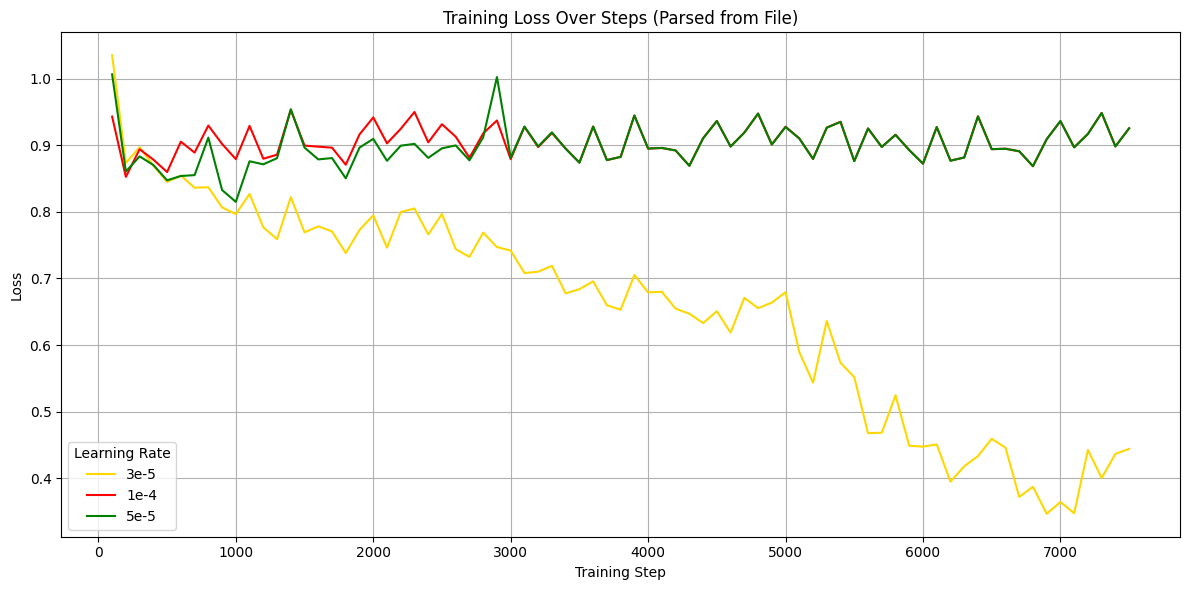

In [20]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

lr_map = {
    "0.0001": "1e-4",
    "5e-05": "5e-5",
    "3e-05": "3e-5",
    "3e-5": "3e-5",
    "5e-5": "5e-5",
    "1e-4": "1e-4"
}

with open(logs_3ep_path, "r") as file:
    log_text = file.read()
    
loss_entries = []
current_lr = None
for line in log_text.splitlines():
    
	if "Running with LR=" in line:
		raw_lr = line.split("Running with LR=")[-1].strip().lower()
		current_lr = lr_map.get(raw_lr, raw_lr)


	match = re.search(r"\[Epoch (\d+) \| Step (\d+)\] loss=([\d.]+)", line)
	if match and current_lr:
		epoch = int(match.group(1))
		step = int(match.group(2))
		global_step = (epoch - 1) * 2500 + step
		loss = float(match.group(3))
		loss_entries.append((global_step, loss, current_lr, epoch))

df_logs = pd.DataFrame(loss_entries, columns=["Step", "Loss", "Learning Rate", "Epoch"])

color_palette = {
    "1e-4": "red",
    "3e-5": "gold",
    "5e-5": "green",
    "0.0001": "red",  # 1e-4
    "0.00005": "green",  # 5e-5
    "0.00003": "gold"  # 3e-5
}

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_logs, x="Step", y="Loss", hue="Learning Rate", palette=color_palette)
plt.title("Training Loss Over Steps (Parsed from File)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()

plot_path = os.path.join(os.path.dirname(logs_3ep_path), "training_loss_plot.png")
plt.savefig(plot_path)
plt.show()

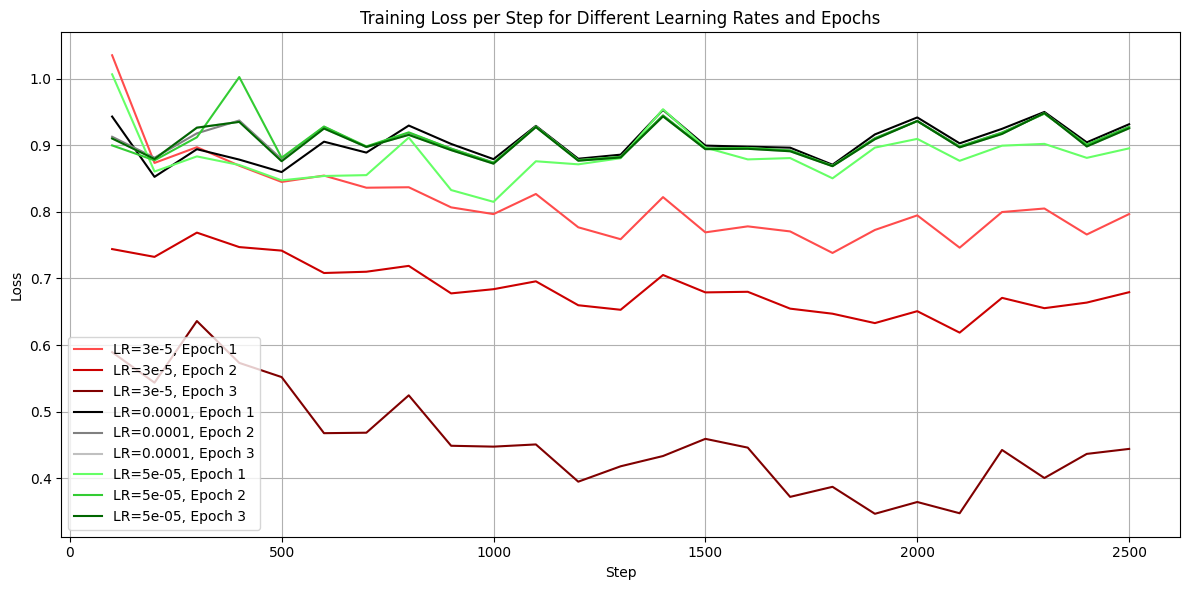

In [24]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

with open(logs_3ep_path, "r") as f:
    log_text = f.read()

pattern_lr = r"Running with LR=([0-9.e-]+)"
pattern_loss = r"\[Epoch (\d+) \| Step (\d+)\] loss=([0-9.]+)"

entries = re.split(pattern_lr, log_text)[1:]  
loss_data = defaultdict(lambda: defaultdict(list))  # lr -> epoch -> list of (step, loss)

for i in range(0, len(entries), 2):
    lr = entries[i]
    log = entries[i + 1]
    for match in re.finditer(pattern_loss, log):
        epoch, step, loss = int(match[1]), int(match[2]), float(match[3])
        loss_data[lr][epoch].append((step, loss))

# custom colors per learning rate
color_shades = {
    "3e-5": ["#ff4c4c", "#cc0000", "#800000"],      # red shades
    "1e-4": ["#4ca3ff", "#0066cc", "#003366"],    # blue shades
    "5e-05": ["#66ff66", "#33cc33", "#006600"],     # green shades
}

plt.figure(figsize=(12, 6))

for lr, epochs in loss_data.items():
    for idx, (epoch, data) in enumerate(sorted(epochs.items())):
        steps, losses = zip(*sorted(data))
        color = color_shades.get(lr, ["black", "gray", "silver"])[idx % 3]  # fallback
        plt.plot(steps, losses, label=f"LR={lr}, Epoch {epoch}", color=color)

plt.title("Training Loss per Step for Different Learning Rates and Epochs")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plot_path = os.path.join(os.path.dirname(logs_3ep_path), "training_loss_plot_per_epoch.png")
plt.savefig(plot_path)
plt.show()


## Result: We are choosing learning rate lr = 3e-5

In [25]:
lr = 3e-5
print("-"*60)
print(f"Running with LR={lr}")
val_acc = train_stage1_claim_only(
	multifc_path=multifc_path,
	output_path=output_claim_only_path,
	roberta_name=MODEL_NAME,
	batch_size=8,
	freeze_until=10,
	lr=lr,
	epochs=10, # run for 10 epochs
	max_len=128,
	nr_model=3 # save model as index = 3
)
if val_acc > best_acc:
	best_acc = val_acc
print("-"*60)
print(f"--> Final val_acc: {val_acc:.4f}")
print("-"*60)
print()
print()

------------------------------------------------------------
Running with LR=3e-05
===== STAGE 1: TRAIN ON MULTIFC (CLAIM-ONLY) =====
Creating datasets and dataloaders...
Initializing model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing bottom 10 layers of RoBERTa...
Setting up optimizer and scheduler...
[Epoch 1 | Step 100] loss=1.0456
[Epoch 1 | Step 200] loss=0.9476
[Epoch 1 | Step 300] loss=0.9217
[Epoch 1 | Step 400] loss=0.9128
[Epoch 1 | Step 500] loss=0.8490
[Epoch 1 | Step 600] loss=0.8683
[Epoch 1 | Step 700] loss=0.8406
[Epoch 1 | Step 800] loss=0.8538
[Epoch 1 | Step 900] loss=0.8123
[Epoch 1 | Step 1000] loss=0.7872
[Epoch 1 | Step 1100] loss=0.8105
[Epoch 1 | Step 1200] loss=0.7790
[Epoch 1 | Step 1300] loss=0.7619
[Epoch 1 | Step 1400] loss=0.8294
[Epoch 1 | Step 1500] loss=0.7704
[Epoch 1 | Step 1600] loss=0.7724
[Epoch 1 | Step 1700] loss=0.7804
[Epoch 1 | Step 1800] loss=0.7363
[Epoch 1 | Step 1900] loss=0.7899
[Epoch 1 | Step 2000] loss=0.7795
[Epoch 1 | Step 2100] loss=0.7509
[Epoch 1 | Step 2200] loss=0.8010
[Epoch 1 | Step 2300] loss=0.8057
[Epoch 1 | Step 2400] loss=0.7701
[Epoch 1 | Step 2500] loss=0.8055
>>> Epoch 1 average train loss: 0.8234
Epoch [1/10] Val loss: 0.7720 | Val Acc: 0

## Plot Results for Training on 10 Epochs

In [52]:
stage1_logs_path = os.path.join(os.getcwd(), "claim-only", "logs_train_10epochs.txt")

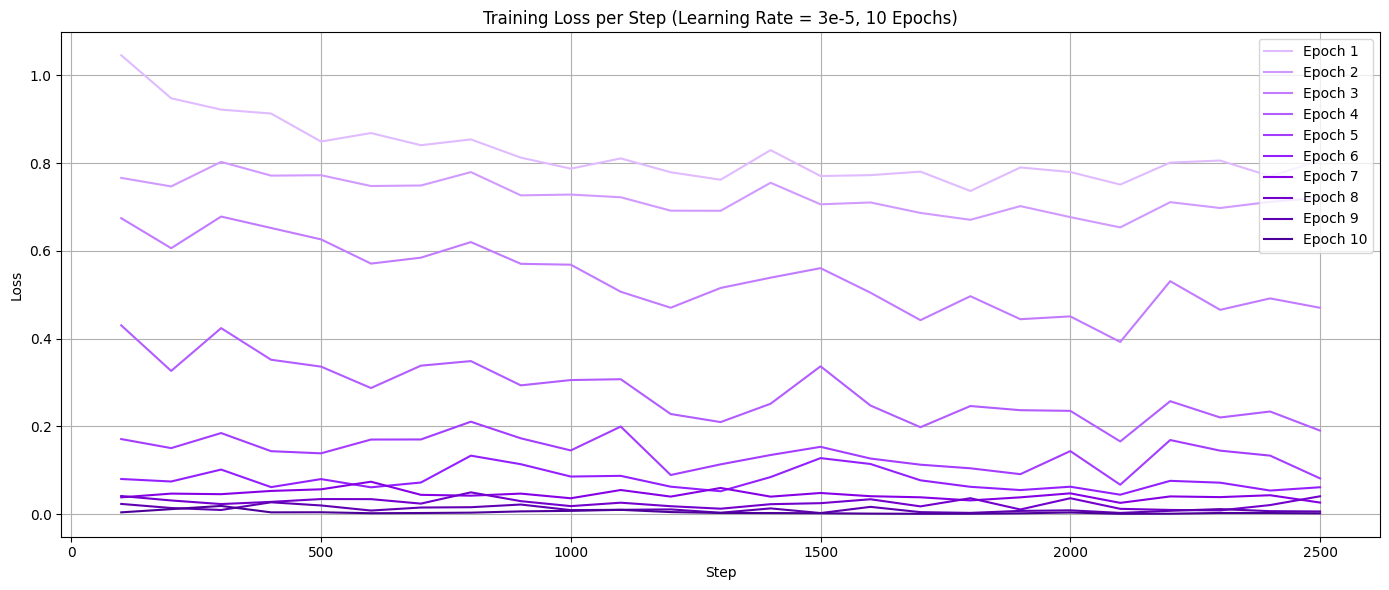

In [55]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

with open(stage1_logs_path, "r") as f:
    log_text = f.read()

pattern_loss = r"\[Epoch (\d+) \| Step (\d+)\] loss=([0-9.]+)"

loss_data = defaultdict(list)

for match in re.finditer(pattern_loss, log_text):
    epoch, step, loss = int(match[1]), int(match[2]), float(match[3])
    loss_data[epoch].append((step, loss))

colors = [
    "#e0bbff", "#d19aff", "#c27bff", "#b35cff", "#a43dff",
    "#9520ff", "#8600e6", "#7300cc", "#6000b3", "#4d0099"
]

plt.figure(figsize=(14, 6))

for idx, (epoch, data) in enumerate(sorted(loss_data.items())):
    steps, losses = zip(*sorted(data))
    plt.plot(steps, losses, label=f"Epoch {epoch}", color=colors[idx % len(colors)])

plt.title("Training Loss per Step (Learning Rate = 3e-5, 10 Epochs)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plot_path = os.path.join(os.path.dirname(logs_3ep_path), "training_loss_10epochs.png")
plt.savefig(plot_path)
plt.show()


## Result: overfitting training data.. not really improving after 3 epochs

## New approach: unfreeze more RoBERTa layers after 2 epochs

In [24]:
def freeze_roberta_layers_v2(model, num_layers_unfrozen=0):
    """
    `num_layers_unfrozen` == 0  → everything frozen  
    `num_layers_unfrozen` == 2 → layers 10-11 train, 0-9 frozen
    """
    total_layers  = 12
    freeze_until  = total_layers - num_layers_unfrozen  # first layer *kept* frozen

    for name, param in model.roberta.named_parameters():
        if "embeddings" in name:          
            param.requires_grad = False
            continue

        # roberta.encoder.layer.<L>....
        if "encoder.layer" in name:
            layer_idx = int(name.split("encoder.layer.")[1].split(".")[0])
            param.requires_grad = layer_idx >= freeze_until
        else:
            # pooler and LM‑head (if present) should stay trainable
            param.requires_grad = True

In [16]:
import numpy as np
from transformers import get_linear_schedule_with_warmup

In [17]:
def evaluate(model, loader, loss_fn):
    # loss, acc, macro f1 on val loader
    model.eval()
    all_preds, all_labels, running_loss = [], [], 0.0
    
    with torch.no_grad():
        for batch in loader:
            inp = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            lbls = batch["label"].to(device)
            
            logits = model(inp, attn)
            running_loss += loss_fn(logits, lbls).item()
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(lbls.cpu().tolist())
            
    model.train()
    val_loss = running_loss / len(loader)
    val_acc = (np.array(all_preds) == np.array(all_labels)).mean()
    val_f1 = f1_score(all_labels, all_preds, average="macro")
    
    return val_loss, val_acc, val_f1


In [41]:
def train_stage1_gradual(
        multifc_path,
        output_path,
        roberta_name=MODEL_NAME,
        batch_size=8,
        lr=3e-5,
        epochs=10,
        warmup_epochs=2,
        freeze_until_init=10,
        freeze_until_phase2=8,
        max_len=128,
		log_interval=100,
        patience=3,
        nr_model=4
):
    
	print("===== STAGE-1 (CLAIM-ONLY) WITH GRADUAL UNFREEZING =====")
	tokenizer = AutoTokenizer.from_pretrained(roberta_name)
	train_path = os.path.join(multifc_path, "train.json")
	val_path = os.path.join(multifc_path, "validation.json")

	data_list_train = load_multifc_claims(train_path)
	data_list_val = load_multifc_claims(val_path)

	print("Creating datasets and dataloaders...")
	train_ds = MultiFCDataset(data_list_train, tokenizer, max_len=max_len)
	val_ds = MultiFCDataset(data_list_val, tokenizer, max_len=max_len)

	train_loader = DataLoader(train_ds, batch_size=batch_size)
	val_loader = DataLoader(val_ds, batch_size=batch_size)

	print("Initializing model...")
	model = BiGRUCNNClassifier(roberta_name=roberta_name,
								hidden_size=128,
								num_labels=3)
	model.to(device)
	
	# ---------------- phase 1 optimiser scheduler ----------------
	print(f"Freezing bottom {freeze_until_init} layers of RoBERTa...")
	freeze_roberta_layers_v2(model, num_layers_unfrozen=(12-freeze_until_init))

	optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
	total_steps = len(train_loader) * epochs
	scheduler = get_linear_schedule_with_warmup(
		optimizer,
		num_warmup_steps=int(0.1*total_steps),
		num_training_steps=total_steps
	)
	criterion = torch.nn.CrossEntropyLoss()

	best_f1, no_improvement = 0.0, 0

	for epoch in range(1, epochs+1):

		# switch to phase 2
		if epoch == warmup_epochs+1:
			print(f"\n[+] Gradual unfreeze: enabling layers "
                  f"{freeze_until_phase2}-11 (was {freeze_until_init}‑11)\n")
			freeze_roberta_layers_v2(model, num_layers_unfrozen=(12-freeze_until_phase2))

			# rebuild optimiser so newly unfrozen params get grads
			head_params, new_params = [], []
			for n, p in model.named_parameters():
				if p.requires_grad:
					if "encoder.layer.%d" % freeze_until_phase2 in n or \
					"encoder.layer.%d" % (freeze_until_phase2+1) in n:
						new_params.append(p)
					else:
						head_params.append(p)

			optimizer = AdamW(
				[{"params": head_params, "lr": lr},
	 			{"params": new_params, "lr": lr*0.5}]			
				)

			### restart scjeduler
			rest_steps = (epochs - epoch + 1) * len(train_loader)
			scheduler = get_linear_schedule_with_warmup(
				optimizer, num_warmup_steps=int(0.05*rest_steps),
				num_training_steps=rest_steps
			)

		# ------- train one epoch --------
		running = 0.0
		total_loss = 0.0
		correct, seen = 0, 0
		for step, batch in enumerate(train_loader, 1):
			optimizer.zero_grad()
			input_ids = batch["input_ids"].to(device)
			attn_mask = batch["attention_mask"].to(device)
			labels = batch["label"].to(device)

			logits = model(input_ids, attn_mask)
			loss = criterion(logits, labels)
			loss.backward()
			optimizer.step()
			scheduler.step()

			running += loss.item()
			total_loss += loss.item()
			correct += (logits.argmax(1)==labels).sum().item()
			seen += labels.size(0)

			if step % log_interval == 0:
				print(f"[Epoch {epoch} | Step {step:>4}/{len(train_loader)}] "
                      f"loss={running/log_interval:.4f}")
				running = 0.0

		avg_train_loss = total_loss / len(train_loader)
		train_acc = correct / seen
		print(f">>> Epoch {epoch} train_loss={avg_train_loss:.4f} | " 
				f"train_acc={train_acc:.4f}")


		# ------------------ validation --------------------------------------
		val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)
		print(f"Epoch [{epoch}/{epochs}] "
				f"Val loss={val_loss:.4f} | Val Acc={val_acc:.4f} | Val F1={val_f1:.4f}")


			# check for early stop?
		if val_f1 > best_f1 + 1e-4:
			best_f1, no_improvement = val_f1, 0
			checkpnt = {
				"model_state": model.state_dict(),
				"val_metrics": {"loss": val_loss, "acc": val_acc, "f1": val_f1},
				"epoch": epoch,
				"unfreeze_plan": {"phase1": freeze_until_init,
								"phase2": freeze_until_phase2			
								}
			}
			
			checkpnt_name = os.path.join(output_path, f"stage1_claim_only{nr_model}.pth")
			torch.save(checkpnt, checkpnt_name)
			print(f"  ↑ new best F1 ({best_f1:.4f}) – model saved to {checkpnt_name}\n")
		else:
			no_improvement += 1
			if no_improvement >= patience:
				print("Early stopping (no val‑F1 improvement).")
				break

	print(f"Training finished. Best macro‑F1 = {best_f1:.4f}")
	return best_f1


In [34]:
freezing_path = os.path.join(output_claim_only_path, "freezing")

In [42]:
freezing_path

'/Users/lorenaandravacarean/Desktop/Fake News/Model/claim-only/freezing'

In [43]:
best_f1score = train_stage1_gradual(
    multifc_path=multifc_path,
    output_path=freezing_path,
    roberta_name=MODEL_NAME,
    batch_size=8,
    lr=3e-5,
    epochs=10,
    warmup_epochs=2,
    freeze_until_init=10,
    freeze_until_phase2=8,
    max_len=128,
    log_interval=100,
    patience=3, 
    nr_model=4 
)

===== STAGE‑1 (CLAIM‑ONLY) WITH GRADUAL UNFREEZING =====
Creating datasets and dataloaders...
Initializing model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing bottom 10 layers of RoBERTa...
[Epoch 1 | Step  100/2553] loss=1.0372
[Epoch 1 | Step  200/2553] loss=0.9674
[Epoch 1 | Step  300/2553] loss=0.9333
[Epoch 1 | Step  400/2553] loss=0.9292
[Epoch 1 | Step  500/2553] loss=0.8621
[Epoch 1 | Step  600/2553] loss=0.9006
[Epoch 1 | Step  700/2553] loss=0.8726
[Epoch 1 | Step  800/2553] loss=0.8788
[Epoch 1 | Step  900/2553] loss=0.8428
[Epoch 1 | Step 1000/2553] loss=0.8087
[Epoch 1 | Step 1100/2553] loss=0.8408
[Epoch 1 | Step 1200/2553] loss=0.7805
[Epoch 1 | Step 1300/2553] loss=0.7815
[Epoch 1 | Step 1400/2553] loss=0.8302
[Epoch 1 | Step 1500/2553] loss=0.7696
[Epoch 1 | Step 1600/2553] loss=0.7685
[Epoch 1 | Step 1700/2553] loss=0.7662
[Epoch 1 | Step 1800/2553] loss=0.7438
[Epoch 1 | Step 1900/2553] loss=0.7743
[Epoch 1 | Step 2000/2553] loss=0.7741
[Epoch 1 | Step 2100/2553] loss=0.7383
[Epoch 1 | Step 2200/2553] loss=0.7819
[Epoch 1 | Step 2300/2553] loss=0.7991
[Epoch 1 | Step 2400/2553] loss=0.7608
[Epoch 1 | Step 2500/255

### Graphing Results

In [44]:
final_stage1_logs_path = os.path.join(os.getcwd(), "claim-only", "freezing", "logs.txt")

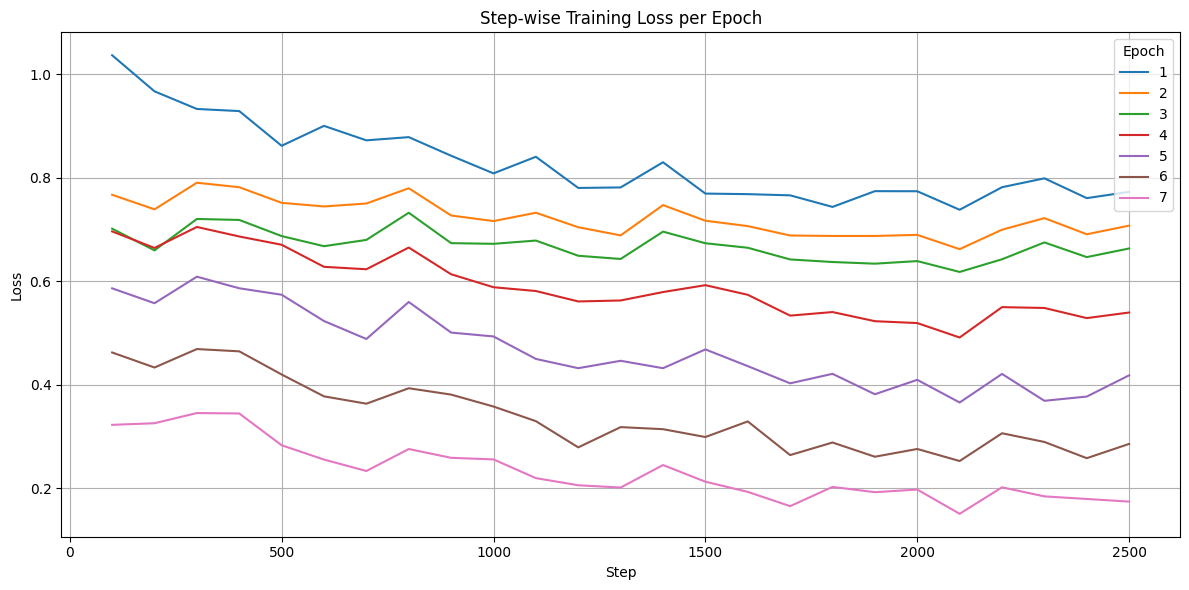

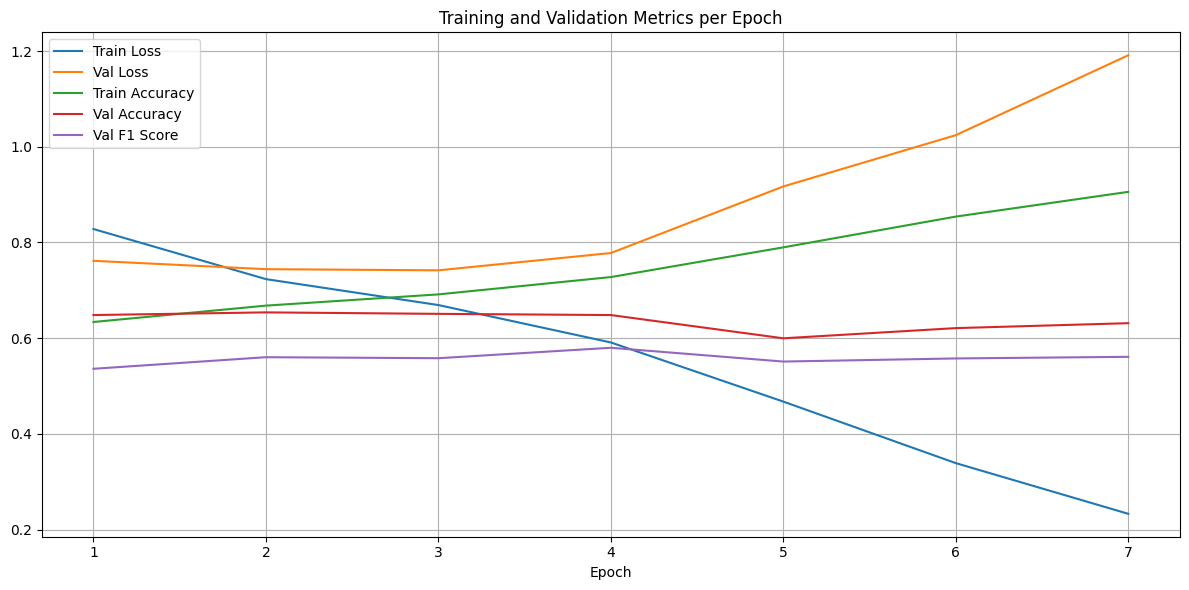

In [56]:
log_file_path = os.path.join(os.getcwd(), "claim-only", "freezing", "logs.txt")

with open(log_file_path, "r") as f:
    log_data = f.read()

step_matches = re.findall(r"\[Epoch (\d+) \| Step\s+(\d+)/\d+\] loss=([\d.]+)", log_data)
step_df = pd.DataFrame(step_matches, columns=["Epoch", "Step", "Loss"])
step_df["Epoch"] = step_df["Epoch"].astype(int)
step_df["Step"] = step_df["Step"].astype(int)
step_df["Loss"] = step_df["Loss"].astype(float)

epoch_matches = re.findall(
    r">>> Epoch (\d+) train_loss=([\d.]+) \| train_acc=([\d.]+)\nEpoch \[\d+/\d+\] Val loss=([\d.]+) \| Val Acc=([\d.]+) \| Val F1=([\d.]+)",
    log_data,
)
epoch_df = pd.DataFrame(epoch_matches, columns=["Epoch", "Train_Loss", "Train_Acc", "Val_Loss", "Val_Acc", "Val_F1"])
epoch_df = epoch_df.astype(float)

import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=step_df, x="Step", y="Loss", hue="Epoch", palette="tab10")
plt.title("Step-wise Training Loss per Epoch")
plt.grid(True)
plt.tight_layout()

plot_path = os.path.join(freezing_path, "step_epoch_train_loss.png")
plt.savefig(plot_path)
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epoch_df["Epoch"], epoch_df["Train_Loss"], label="Train Loss")
plt.plot(epoch_df["Epoch"], epoch_df["Val_Loss"], label="Val Loss")
plt.plot(epoch_df["Epoch"], epoch_df["Train_Acc"], label="Train Accuracy")
plt.plot(epoch_df["Epoch"], epoch_df["Val_Acc"], label="Val Accuracy")
plt.plot(epoch_df["Epoch"], epoch_df["Val_F1"], label="Val F1 Score")
plt.xlabel("Epoch")
plt.title("Training and Validation Metrics per Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()


plot_path = os.path.join(freezing_path, "metrics_per_epoch.png")
plt.savefig(plot_path)
plt.show()


,train_loss,train_acc,val_loss,val_f1
epoch,,,,
1,0.8281,0.6338,0.7617,0.5360
2,0.7234,0.6680,0.7442,0.5602
3,0.6692,0.6915,0.7418,0.5581
4,0.5910,0.7277,0.7779,0.5799
5,0.4674,0.7898,0.9171,0.5511
6,0.3388,0.8541,1.0243,0.5576
7,0.2329,0.9058,1.1913,0.5610


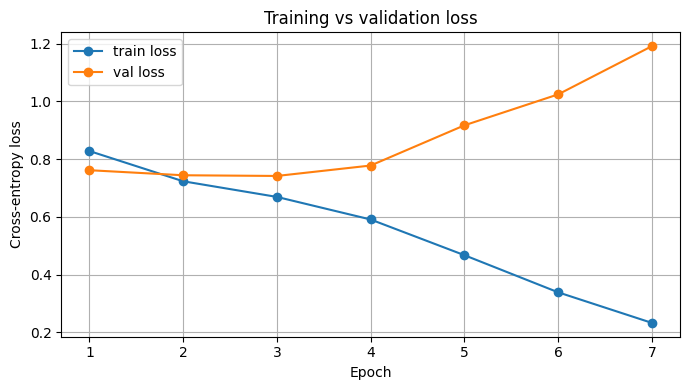

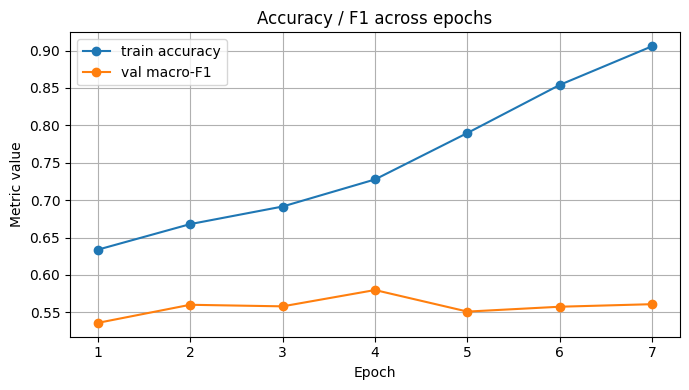

In [ ]:
from pathlib import Path
final_stage1_logs_path = Path.cwd() / "claim-only" / "freezing" / "logs.txt"
log_text = final_stage1_logs_path.read_text()

pattern = re.compile(
    r">>> Epoch (\d+) train_loss=([\d.]+) \| train_acc=([\d.]+).*?"
    r"Epoch \[\1/\d+\] Val loss=([\d.]+) \| Val Acc=[\d.]+ \| Val F1=([\d.]+)",
    re.S)
records = []
for m in pattern.finditer(log_text):
    epoch  = int(m.group(1))
    tr_loss= float(m.group(2)); tr_acc = float(m.group(3))
    val_loss=float(m.group(4)); val_f1 = float(m.group(5))
    records.append((epoch, tr_loss, tr_acc, val_loss, val_f1))

df = pd.DataFrame(records,
                  columns=["epoch","train_loss","train_acc",
                           "val_loss","val_f1"]).set_index("epoch")
display(df)                 



plt.figure(figsize=(7,4))
plt.plot(df.index, df.train_loss, marker='o', label="train loss")
plt.plot(df.index, df.val_loss,   marker='o', label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Cross‑entropy loss")
plt.title("Training vs validation loss")
plt.grid(True); plt.legend(); plt.tight_layout()

plot_path = os.path.join(freezing_path, "train_vs_val_loss_epochs.png")
plt.savefig(plot_path)
plt.show()



plt.figure(figsize=(7,4))
plt.plot(df.index, df.train_acc, marker='o', label="train accuracy")
plt.plot(df.index, df.val_f1,   marker='o', label="val macro‑F1")
plt.xlabel("Epoch"); plt.ylabel("Metric value")
plt.title("Accuracy / F1 across epochs")
plt.grid(True); plt.legend(); plt.tight_layout()

plot_path = os.path.join(freezing_path, "acc_f1_epochs.png")
plt.savefig(plot_path)
plt.show()

# Stage 2: Train on (Claim, Evidence)

#### Load Stage 1 Checkpoint

In [13]:
stage1_checkpoint_path = os.path.join(os.getcwd(), "claim-only", "freezing", "stage1_claim_only4.pth")

In [18]:
out_dir_stage2 = os.path.join(os.getcwd(), "claim+evidence")

In [19]:
import gc
import copy
import torch
import torch.nn.functional as F


In [ ]:
learning_rates = [3e-5, 5e-5, 1e-5]

In [16]:
device

device(type='mps')

In [20]:
fever_claims_path = os.path.join(os.getcwd(), "Dataset", "fever")
fever_train_path = os.path.join(fever_claims_path, "train.json")
fever_val_path = os.path.join(fever_claims_path, "validation.json")

In [88]:
def train_stage2_prep():
    
	train_data = load_fever_claims(fever_train_path)
	val_data = load_fever_claims(fever_val_path)
	tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
	train_dataset = FeverDataset(train_data, tokenizer)
	val_dataset = FeverDataset(val_data, tokenizer)

	candidate_batch_sizes = [8, 4, 2, 1]
	batch_size = None
	# load stage 1 model
	ckpt = torch.load(stage1_checkpoint_path, map_location="cpu", weights_only=False)
	initial_state = copy.deepcopy(ckpt["model_state"])
	for b_s in candidate_batch_sizes:
		try:
			train_loader_test = DataLoader(train_dataset, batch_size=b_s, shuffle=True, num_workers=0)

			test_model = BiGRUCNNClassifier()
			test_model.load_state_dict(initial_state)
			test_model.to(device)
			test_model.train()

			batch = next(iter(train_loader_test))
			input_ids  = batch["input_ids"].to(device)
			attention_mask = batch["attention_mask"].to(device)
			labels     = batch["label"].to(device)

			outputs = test_model(input_ids, attention_mask)
			loss = F.cross_entropy(outputs, labels)
			loss.backward()
			batch_size = b_s
			del test_model, batch, outputs, loss, train_loader_test

			if device.type == "mps":
				torch.mps.empty_cache()
			break

		except RuntimeError as e:
			if "out of memory" in str(e).lower():
				print(f"Batch size {b_s} is too large, trying smaller batch size...")
				if device.type == "cuda":
					torch.cuda.empty_cache()
				elif device.type == "mps":
					torch.mps.empty_cache()
                # continue to next smaller batch size
				continue
			else:
				raise e
			
		finally:
			gc.collect()					
			torch.mps.empty_cache()

	

	if batch_size is None:
		raise RuntimeError("Unable to find a feasible batch size (not even 1 worked)")
	else:
		print(f"Using batch size = {batch_size}")

	
	# now we can successfully proceed to training
	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
	val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


	candidate_learning_rates = [3e-5, 5e-5, 1e-5]
	best_lr = None
	best_val_f1 = 0.0
	print("\nStarting testing for learning rates...")
	for lr in candidate_learning_rates:
		model = BiGRUCNNClassifier()
		model.load_state_dict(initial_state)
		model.to(device)
		freeze_roberta_layers(model, num_layers_unfrozen=2)
		optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
		total_steps = len(train_loader) * 3
		warmup_steps = int(0.1 * total_steps)
		if get_linear_schedule_with_warmup:
			scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

		else:
			def lr_lambda(step):
				if step < warmup_steps:
					return float(step) / float(max(1, warmup_steps))
				return max(0.0, float(total_steps - step) / float(max(1, total_steps - warmup_steps)))
			scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        

		best_f1_this_lr = 0.0
		
		for epoch in range (1, 4):
			model.train()
			running_loss = 0.0
			for step, batch in enumerate(train_loader, start=1):
				input_ids  = batch["input_ids"].to(device)
				attention_mask = batch["attention_mask"].to(device)
				labels     = batch["label"].to(device)

				optimizer.zero_grad()
				outputs = model(input_ids, attention_mask)
				loss = F.cross_entropy(outputs, labels)
				loss.backward()
				optimizer.step()
				scheduler.step()
				running_loss += loss.item()

				if step % 100 == 0:
					avg_loss = running_loss / 100
					print(f"[LR={lr}] Epoch {epoch}, Step {step}, Avg Train Loss: {avg_loss:.4f}")
					running_loss = 0.0
				
			val_loss, val_acc, val_f1 = evaluate(model, val_loader, torch.nn.CrossEntropyLoss())
			print(f"Epoch {epoch}  val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

			if val_f1 > best_f1_this_lr:
				best_f1_this_lr = val_f1

			if epoch == 2:
				freeze_roberta_layers(model, num_layers_unfrozen=4)
		
		print(f"LR={lr} run complete. Best Validation Macro-F1 = {best_f1_this_lr:.4f}\n")
		if best_f1_this_lr > best_val_f1:
			best_val_f1 = best_f1_this_lr
			best_lr = lr

		del model, optimizer, scheduler
		torch.mps.empty_cache()

	print(f"Learning rate sweep finished. Best LR = {best_lr} (Val Macro-F1 = {best_val_f1:.4f})")



In [89]:
train_stage2_prep()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using batch size = 8

Starting testing for learning rates...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[LR=3e-05] Epoch 1, Step 100, Avg Train Loss: 1.3435
[LR=3e-05] Epoch 1, Step 200, Avg Train Loss: 1.1267
[LR=3e-05] Epoch 1, Step 300, Avg Train Loss: 0.9248
[LR=3e-05] Epoch 1, Step 400, Avg Train Loss: 0.7732
[LR=3e-05] Epoch 1, Step 500, Avg Train Loss: 0.5738
[LR=3e-05] Epoch 1, Step 600, Avg Train Loss: 0.4044
[LR=3e-05] Epoch 1, Step 700, Avg Train Loss: 0.4017
[LR=3e-05] Epoch 1, Step 800, Avg Train Loss: 0.3482
[LR=3e-05] Epoch 1, Step 900, Avg Train Loss: 0.2638
[LR=3e-05] Epoch 1, Step 1000, Avg Train Loss: 0.2562
[LR=3e-05] Epoch 1, Step 1100, Avg Train Loss: 0.2555
[LR=3e-05] Epoch 1, Step 1200, Avg Train Loss: 0.1968
[LR=3e-05] Epoch 1, Step 1300, Avg Train Loss: 0.1990
[LR=3e-05] Epoch 1, Step 1400, Avg Train Loss: 0.2119
[LR=3e-05] Epoch 1, Step 1500, Avg Train Loss: 0.2100
[LR=3e-05] Epoch 1, Step 1600, Avg Train Loss: 0.1728
[LR=3e-05] Epoch 1, Step 1700, Avg Train Loss: 0.2097
[LR=3e-05] Epoch 1, Step 1800, Avg Train Loss: 0.2196
[LR=3e-05] Epoch 1, Step 1900, Avg Tr

KeyboardInterrupt: 

# ----------------------

In [28]:
def try_batch_size():
    
	train_data = load_fever_claims(fever_train_path)
	val_data = load_fever_claims(fever_val_path)
	tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
	train_dataset = FeverDataset(train_data, tokenizer)
	val_dataset = FeverDataset(val_data, tokenizer)

	candidate_batch_sizes = [64, 32, 16, 8, 4, 2, 1]
	batch_size = None
	# load stage 1 model
	ckpt = torch.load(stage1_checkpoint_path, map_location="cpu", weights_only=False)
	initial_state = copy.deepcopy(ckpt["model_state"])
	for b_s in candidate_batch_sizes:
		try:
			train_loader_test = DataLoader(train_dataset, batch_size=b_s, shuffle=True, num_workers=0)

			test_model = BiGRUCNNClassifier()
			test_model.load_state_dict(initial_state)
			test_model.to(device)
			test_model.train()

			batch = next(iter(train_loader_test))
			input_ids  = batch["input_ids"].to(device)
			attention_mask = batch["attention_mask"].to(device)
			labels     = batch["label"].to(device)

			outputs = test_model(input_ids, attention_mask)
			loss = F.cross_entropy(outputs, labels)
			loss.backward()
			batch_size = b_s
			del test_model, batch, outputs, loss, train_loader_test

			if device.type == "mps":
				torch.mps.empty_cache()
			break

		except RuntimeError as e:
			if "out of memory" in str(e).lower():
				print(f"Batch size {b_s} is too large, trying smaller batch size...")
				if device.type == "cuda":
					torch.cuda.empty_cache()
				elif device.type == "mps":
					torch.mps.empty_cache()
                # continue to next smaller batch size
				continue
			else:
				raise e
			
		finally:
			gc.collect()					
			torch.mps.empty_cache()

	

	if batch_size is None:
		raise RuntimeError("Unable to find a feasible batch size (not even 1 worked)")
	else:
		print(f"Using batch size = {batch_size}")

	
	

In [29]:
try_batch_size()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Batch size 64 is too large, trying smaller batch size...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using batch size = 32


In [21]:
best_lr = 3e-5 
batch_size = 32

In [35]:
def train_stage2():
	# ===== Stage 2: Full Training with Best LR and Early Stopping =====
    ckpt = torch.load(stage1_checkpoint_path, map_location="cpu", weights_only=False)
    model = BiGRUCNNClassifier()
    model.load_state_dict(ckpt["model_state"])
    model.to(device)
    # start with bottom 10 layers frozen
    freeze_roberta_layers(model, num_layers_unfrozen=2)
    optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=1e-2)
    
    train_data = load_fever_claims(fever_train_path)
    val_data = load_fever_claims(fever_val_path)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    train_dataset = FeverDataset(train_data, tokenizer)
    val_dataset = FeverDataset(val_data, tokenizer)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)



    total_steps = len(train_loader) * 10 
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    loss_fn = torch.nn.CrossEntropyLoss()
        
    print(f"\nStarting final training with best LR = {best_lr}...")
    best_val_f1_final = 0.0
    epochs_no_improve = 0
    
    for epoch in range(1, 11):
        model.train()
        running_loss = 0.0
        print()
        for step, batch in enumerate(train_loader, start=1):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

            if step % 100 == 0:
                avg_loss = running_loss / 100
                print(f"Epoch {epoch}, Step {step}, Avg Train Loss: {avg_loss:.4f}")
                running_loss = 0.0
        # Gradual unfreezing: unfreeze 2 more layers at epoch 2,4,6,8
        if epoch == 2:
            freeze_roberta_layers(model, 4)
            print("Unfroze 2 additional RoBERTa layers (now bottom 8 layers frozen).")
        elif epoch == 4:
            freeze_roberta_layers(model, 6)
            print("Unfroze 2 additional RoBERTa layers (now bottom 6 layers frozen).")
        elif epoch == 6:
            freeze_roberta_layers(model, 8)
            print("Unfroze 2 additional RoBERTa layers (now bottom 4 layers frozen).")
        elif epoch == 8:
            freeze_roberta_layers(model, 10)
            print("Unfroze 2 additional RoBERTa layers (now bottom 2 layers frozen).")
        elif epoch == 10:
            freeze_roberta_layers(model, 12)
            print("Unfroze all remaining RoBERTa layers (model is fully trainable).")


        v_loss, v_acc, v_f1 = evaluate(model, val_loader, loss_fn)
        print(f"Ep {epoch:02d}  val_loss={v_loss:.4f} | val_acc={v_acc:.4f} | "
              f"val_f1={v_f1:.4f}")
        # save checkpoint for this epoch
        ckpt_name = f"stage2_epoch{epoch}_valf1{v_f1:.4f}.pth"
        torch.save(model.state_dict(), ckpt_name)
        print(f"Saved checkpoint: {ckpt_name}")
        
        # check for improvement
        if val_f1 > best_val_f1_final:
            best_val_f1_final = val_f1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        # early stopping: stop if no improvement in 3 consecutive epochs
        if epochs_no_improve >= 3:
            print("Early stopping triggered (no val F1 improvement in 3 epochs).")
            break
        
        if device.type == "mps":
            torch.mps.empty_cache()
    print(f"Training complete. Best validation Macro-F1: {best_val_f1_final:.4f}")
    
	

In [36]:
train_stage2()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting final training with best LR = 3e-05...

Epoch 1, Step 100, Avg Train Loss: 1.4733
Epoch 1, Step 200, Avg Train Loss: 1.3090
Epoch 1, Step 300, Avg Train Loss: 1.1376
Epoch 1, Step 400, Avg Train Loss: 1.0271
Epoch 1, Step 500, Avg Train Loss: 0.9120
Epoch 1, Step 600, Avg Train Loss: 0.8471
Epoch 1, Step 700, Avg Train Loss: 0.7651
Epoch 1, Step 800, Avg Train Loss: 0.6528
Epoch 1, Step 900, Avg Train Loss: 0.5514
Epoch 1, Step 1000, Avg Train Loss: 0.5020
Epoch 1, Step 1100, Avg Train Loss: 0.4175
Epoch 1, Step 1200, Avg Train Loss: 0.3733
Epoch 1, Step 1300, Avg Train Loss: 0.3552
Epoch 1, Step 1400, Avg Train Loss: 0.3350
Epoch 1, Step 1500, Avg Train Loss: 0.3012
Epoch 1, Step 1600, Avg Train Loss: 0.2786
Epoch 1, Step 1700, Avg Train Loss: 0.2452
Epoch 1, Step 1800, Avg Train Loss: 0.2269
Epoch 1, Step 1900, Avg Train Loss: 0.2781
Epoch 1, Step 2000, Avg Train Loss: 0.2150
Epoch 1, Step 2100, Avg Train Loss: 0.2325
Epoch 1, Step 2200, Avg Train Loss: 0.1695
Epoch 1, Step

NameError: name 'val_f1' is not defined

In [22]:
os.getcwd()

'/Users/lorenaandravacarean/Desktop/Fake News/Model'

In [34]:
def train_stage2_continue():
    # ---------------- checkpoint / resume -----------------
    ckpt_path = os.path.join(os.getcwd(), "stage2_epoch1_valf10.9477.pth")
    start_epoch = 1
    model      = BiGRUCNNClassifier().to(device)
    
    if ckpt_path:
        print(f"Resuming from {ckpt_path}")
        payload = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        model.load_state_dict(payload)
        start_epoch = 2
        best_val_f1_final = 0.9477
    else:
        print("Starting fresh Stage-2 training")
        # ====== stage-1 init ======
        stage1 = torch.load(stage1_checkpoint_path, map_location="cpu", weights_only=False)
        model.load_state_dict(stage1["model_state"])
        best_val_f1_final = 0.0


    optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=1e-2)
    
    train_data = load_fever_claims(fever_train_path)
    val_data = load_fever_claims(fever_val_path)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    train_dataset = FeverDataset(train_data, tokenizer)
    val_dataset = FeverDataset(val_data, tokenizer)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)



    total_steps = len(train_loader) * 10 
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    loss_fn = torch.nn.CrossEntropyLoss()

    freeze_roberta_layers(model, num_layers_unfrozen=2)

    # ------------------- training loop -------------------
    epochs_no_improve = 0
    
    for epoch in range(start_epoch, 11):
        model.train()
        running_loss = 0.0
        for step, batch in enumerate(train_loader, 1):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels   = batch["label"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

            if step % 100 == 0:
                avg_loss = running_loss / 100
                print(f"Epoch {epoch}, Step {step}, Avg Train Loss: {avg_loss:.4f}")
                running_loss = 0.0

        # gradual unfreeze (same logic as before)
        if epoch == 2:
            freeze_roberta_layers(model, 4)
            print("Unfroze 2 additional RoBERTa layers (now bottom 8 layers frozen).")
        elif epoch == 4:
            freeze_roberta_layers(model, 6)
            print("Unfroze 2 additional RoBERTa layers (now bottom 6 layers frozen).")
        elif epoch == 6:
            freeze_roberta_layers(model, 8)
            print("Unfroze 2 additional RoBERTa layers (now bottom 4 layers frozen).")
        elif epoch == 8:
            freeze_roberta_layers(model, 10)
            print("Unfroze 2 additional RoBERTa layers (now bottom 2 layers frozen).")
        elif epoch == 10:
            freeze_roberta_layers(model, 12)
            print("Unfroze all remaining RoBERTa layers (model is fully trainable).")

        v_loss, v_acc, v_f1 = evaluate(model, val_loader, loss_fn)
        print(f"Ep {epoch:02d}  val_loss={v_loss:.4f} | val_acc={v_acc:.4f} | "
              f"val_f1={v_f1:.4f}")
        

        
        ckpt_name = f"stage2_epoch{epoch}_valf1{v_f1:.4f}.pth"
        torch.save(model.state_dict(), os.path.join(os.getcwd(), "claim+evidence", ckpt_name))
        print(f"Saved checkpoint: {ckpt_name}")
        

        # early-stopping bookkeeping
        if v_f1 > best_val_f1_final + 1e-4:
            best_val_f1_final = v_f1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= 3:
                print("Early stopping (no val-F1 gain in 3 epochs).")
                break

        if device.type == "mps":
            torch.mps.empty_cache()

    print("Best validation F1:", best_val_f1_final)


In [35]:
train_stage2_continue()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Resuming from /Users/lorenaandravacarean/Desktop/Fake News/Model/stage2_epoch1_valf10.9477.pth
Epoch 2, Step 100, Avg Train Loss: 0.1190
Epoch 2, Step 200, Avg Train Loss: 0.1135
Epoch 2, Step 300, Avg Train Loss: 0.1061
Epoch 2, Step 400, Avg Train Loss: 0.0975
Epoch 2, Step 500, Avg Train Loss: 0.1035
Epoch 2, Step 600, Avg Train Loss: 0.0856
Epoch 2, Step 700, Avg Train Loss: 0.0888
Epoch 2, Step 800, Avg Train Loss: 0.0903
Epoch 2, Step 900, Avg Train Loss: 0.0891
Epoch 2, Step 1000, Avg Train Loss: 0.0666
Epoch 2, Step 1100, Avg Train Loss: 0.0862
Epoch 2, Step 1200, Avg Train Loss: 0.0762
Epoch 2, Step 1300, Avg Train Loss: 0.0800
Epoch 2, Step 1400, Avg Train Loss: 0.0729
Epoch 2, Step 1500, Avg Train Loss: 0.0635
Epoch 2, Step 1600, Avg Train Loss: 0.0907
Epoch 2, Step 1700, Avg Train Loss: 0.0775
Epoch 2, Step 1800, Avg Train Loss: 0.0768
Epoch 2, Step 1900, Avg Train Loss: 0.0854
Epoch 2, Step 2000, Avg Train Loss: 0.0846
Epoch 2, Step 2100, Avg Train Loss: 0.0819
Epoch 2, St